<a href="https://colab.research.google.com/github/saradindu-chaudhuri/SC/blob/master/CHeBA_Interpretable_ML_Alzheimers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd

# Load the dataset
df = pd.read_csv('alzheimers_disease_data.csv')

# Display basic information and first 5 rows
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [15]:
!pip install shap


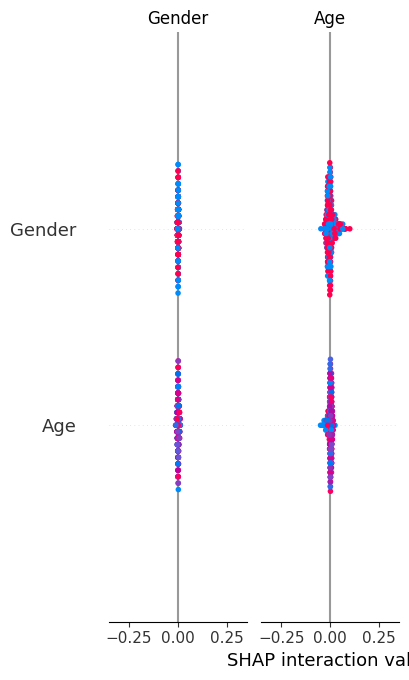

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap

# 1. Clean up columns - drop IDs or non-predictive text columns
X = df.drop(columns=['PatientID', 'DoctorInCharge', 'Diagnosis'])
y = df['Diagnosis']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Generate SHAP values for Model Interpretability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 5. Plot SHAP Summary
# (If shap_values is a list for binary classification, use index 1 for positive class)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

 99%|===================| 853/860 [00:18<00:00]       

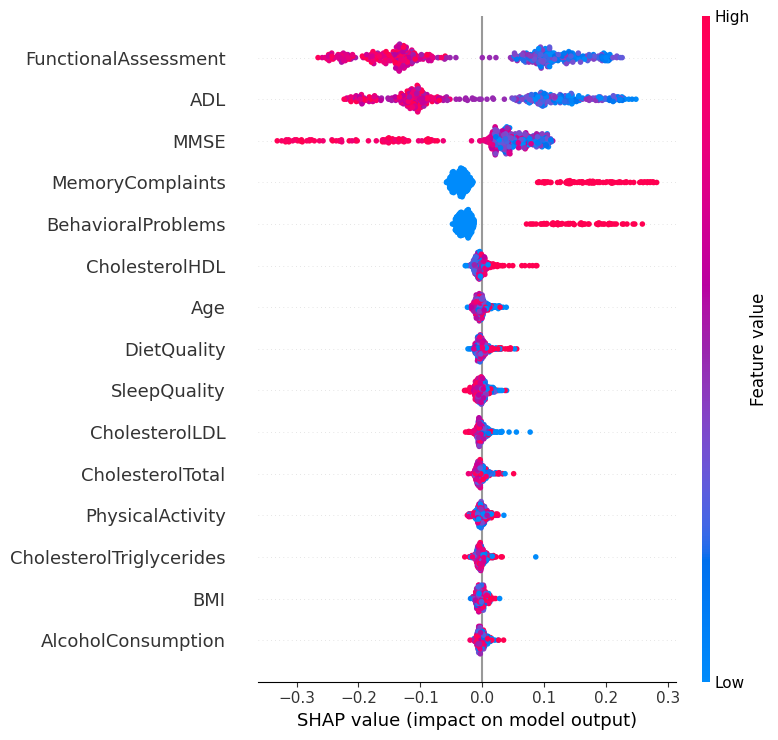

In [17]:
import shap

# 1. Ensure X only contains numeric features for the model
X = df.drop(columns=['PatientID', 'DoctorInCharge', 'Diagnosis'], errors='ignore')

# Convert any categorical/object columns to numeric/dummies if needed
X = pd.get_dummies(X, drop_first=True)
y = df['Diagnosis']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Compute SHAP Values using Explainer
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# 5. Plot Summary for Class 1 (Alzheimer's Diagnosis)
# If binary, shap_values[:, :, 1] isolates the positive diagnosis class
if len(shap_values.shape) == 3:
    shap.summary_plot(shap_values[:, :, 1], X_test, max_display=15)
else:
    shap.summary_plot(shap_values, X_test, max_display=15)

### Baseline Model Interpretability Results (Alzheimer's Dataset)
- **Model:** Random Forest Classifier evaluated using SHAP (SHapley Additive exPlanations) values.
- **Primary Features:** `FunctionalAssessment`, `ADL`, and `MMSE` demonstrate the highest impact on diagnostic classification.
- **Clinical Alignment:** Low MMSE scores combined with active memory/behavioral complaints show strong positive feature attribution toward dementia prediction, aligning with clinical consensus.